# Phase 2C: Feature Quality Analysis & Selection

## Objectives
1. Analyze distributions of all 25 new features (timestomped vs benign)
2. Calculate correlation matrix to identify redundant features
3. Train preliminary Random Forest to get feature importance rankings
4. Select top 20-25 high-quality features
5. Fix path_depth bug if important, otherwise drop it
6. Create final ML-ready dataset for Phase 3

## Input
- **File**: `data/processed/Phase 2B - Cross Artifact and Pattern Features/all_cases_combined_with_phase2b_features.csv`
- **Records**: 154,550
- **Columns**: 63 (38 baseline + 25 new features)
- **Timestomped**: 252 (0.16%)

## Expected Output
- Curated dataset with 20-25 high-quality features
- Feature importance rankings
- Correlation heatmap
- Distribution plots for all features
- Feature quality analysis report

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


## Step 1: Load Data

In [33]:
# Define paths
BASE_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis')
INPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 2B - Cross Artifact and Pattern Features'
OUTPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 2C - Feature Quality'

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("📂 Directory Configuration:")
print(f"  Input: {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")

# Load Phase 2B dataset
print("\nLoading Phase 2B dataset...")
df = pd.read_csv(INPUT_DIR / 'all_cases_combined_with_phase2b_features.csv', encoding='utf-8-sig')

# Convert is_timestomped to boolean for filtering
df['is_timestomped'] = df['is_timestomped'].astype(bool)

print(f"\n✓ Loaded dataset:")
print(f"  Records: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print(f"  Timestomped events: {df['is_timestomped'].sum():,}")
print(f"  Benign events: {(~df['is_timestomped']).sum():,}")
print(f"\nDataset shape: {df.shape}")

📂 Directory Configuration:
  Input: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2B - Cross Artifact and Pattern Features
  Output: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2C - Feature Quality

Loading Phase 2B dataset...

✓ Loaded dataset:
  Records: 154,550
  Columns: 63
  Timestomped events: 252
  Benign events: 154,298

Dataset shape: (154550, 63)


## Step 2: Define Feature Groups

We created 25 new features across 4 groups:
- **Group 1A**: Location features (6)
- **Group 1B**: File type features (6)
- **Group 1C**: Temporal behavioral features (6)
- **Group 2**: Cross-artifact features (3)
- **Group 3**: UsnJrnl pattern features (3)
- **Group 4**: Event-time comparison (1)

In [34]:
# Define all 25 new features by group
location_features = [
    'in_system32', 'in_windows_dir', 'in_temp_dir', 
    'in_program_files', 'in_users_dir', 'path_depth'
]

file_type_features = [
    'is_executable', 'is_system_file', 'is_hidden_file',
    'is_archive', 'filename_length', 'has_suspicious_extension'
]

temporal_features = [
    'event_frequency_per_file', 'event_frequency_per_case',
    'events_in_1min_window', 'events_in_5min_window',
    'time_since_previous_event_seconds', 'time_until_next_event_seconds'
]

cross_artifact_features = [
    'source_confidence_score', 'has_logfile_evidence', 'has_usnjrnl_evidence'
]

pattern_features = [
    'usn_basic_info_change', 'usn_file_closed', 'usn_complete_manipulation_pattern'
]

event_time_features = [
    'event_vs_modified_after_days'
]

# All 25 new features
all_new_features = (
    location_features + file_type_features + temporal_features + 
    cross_artifact_features + pattern_features + event_time_features
)

print(f"Total new features: {len(all_new_features)}")
print(f"\nFeature groups:")
print(f"  - Location: {len(location_features)}")
print(f"  - File type: {len(file_type_features)}")
print(f"  - Temporal: {len(temporal_features)}")
print(f"  - Cross-artifact: {len(cross_artifact_features)}")
print(f"  - Patterns: {len(pattern_features)}")
print(f"  - Event-time: {len(event_time_features)}")

# Verify all features exist in dataframe
missing_features = [f for f in all_new_features if f not in df.columns]
if missing_features:
    print(f"\n⚠️ WARNING: Missing features: {missing_features}")
else:
    print(f"\n✓ All 25 features found in dataset")

Total new features: 25

Feature groups:
  - Location: 6
  - File type: 6
  - Temporal: 6
  - Cross-artifact: 3
  - Patterns: 3
  - Event-time: 1

✓ All 25 features found in dataset


## Step 3: Check for path_depth Bug

Known issue from Phase 2A/2B: path_depth shows 0 for all records due to regex bug.

In [35]:
# Check path_depth values
print("path_depth statistics:")
print(df['path_depth'].describe())
print(f"\nUnique values: {df['path_depth'].unique()}")
print(f"Non-zero count: {(df['path_depth'] > 0).sum():,}")

if df['path_depth'].max() == 0:
    print("\n⚠️ CONFIRMED: path_depth bug still present (all zeros)")
    print("   Will fix now before proceeding...")
    
    # FIX: Use correct regex to count single backslashes
    df['path_depth'] = df['filepath'].fillna('').astype(str).str.count(r'\\')
    
    print("\n✓ path_depth FIXED!")
    print("\nNew statistics:")
    print(df['path_depth'].describe())
    print(f"Non-zero count: {(df['path_depth'] > 0).sum():,}")
else:
    print("\n✓ path_depth already has valid values")

path_depth statistics:
count    154550.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: path_depth, dtype: float64

Unique values: [0]
Non-zero count: 0

⚠️ CONFIRMED: path_depth bug still present (all zeros)
   Will fix now before proceeding...

✓ path_depth FIXED!

New statistics:
count    154550.000000
mean          3.739502
std           2.849085
min           0.000000
25%           0.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: path_depth, dtype: float64
Non-zero count: 108,933


## Step 4: Distribution Analysis - Boolean Features

Plot TRUE percentage for all boolean features (timestomped vs benign).

Boolean Features - TRUE Percentage Comparison:
in_temp_dir                              | TS:  90.87% | Benign:   3.22% | Ratio: 28.20x
has_logfile_evidence                     | TS:   5.56% | Benign:   2.00% | Ratio: 2.78x
is_archive                               | TS:  96.83% | Benign:  44.00% | Ratio: 2.20x
in_windows_dir                           | TS:  90.87% | Benign:  47.94% | Ratio: 1.90x
usn_file_closed                          | TS:  94.44% | Benign:  52.22% | Ratio: 1.81x
usn_complete_manipulation_pattern        | TS:  94.44% | Benign:  52.22% | Ratio: 1.81x
in_program_files                         | TS:   8.73% | Benign:   5.82% | Ratio: 1.50x
has_usnjrnl_evidence                     | TS:  96.83% | Benign:  99.85% | Ratio: 0.97x
usn_basic_info_change                    | TS:  96.83% | Benign:  99.85% | Ratio: 0.97x
is_executable                            | TS:   9.13% | Benign:  23.04% | Ratio: 0.40x
in_system32                              | TS:   0.00% | Benign:   5.69%

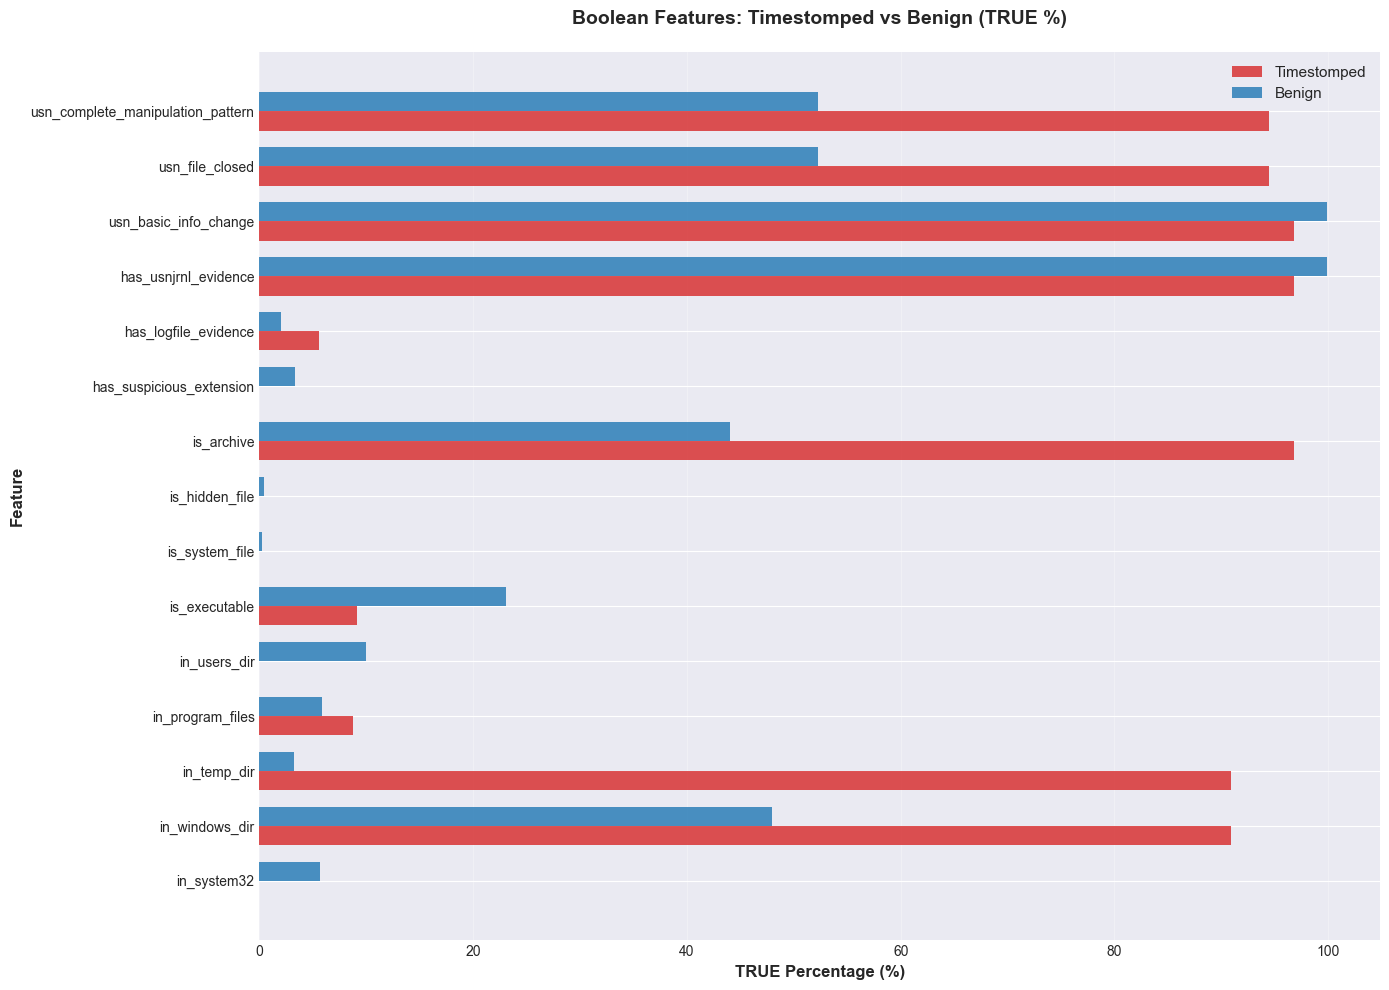

In [36]:
# Identify boolean features
boolean_features = [
    'in_system32', 'in_windows_dir', 'in_temp_dir', 'in_program_files', 'in_users_dir',
    'is_executable', 'is_system_file', 'is_hidden_file', 'is_archive', 'has_suspicious_extension',
    'has_logfile_evidence', 'has_usnjrnl_evidence',
    'usn_basic_info_change', 'usn_file_closed', 'usn_complete_manipulation_pattern'
]

# Calculate TRUE percentages for timestomped vs benign
bool_stats = []
for feature in boolean_features:
    ts_pct = df[df['is_timestomped']][feature].mean() * 100
    benign_pct = df[~df['is_timestomped']][feature].mean() * 100
    ratio = ts_pct / benign_pct if benign_pct > 0 else 0
    
    bool_stats.append({
        'feature': feature,
        'timestomped_pct': ts_pct,
        'benign_pct': benign_pct,
        'ratio': ratio
    })

bool_df = pd.DataFrame(bool_stats)
bool_df = bool_df.sort_values('ratio', ascending=False)

print("Boolean Features - TRUE Percentage Comparison:")
print("=" * 80)
for _, row in bool_df.iterrows():
    print(f"{row['feature']:40s} | TS: {row['timestomped_pct']:6.2f}% | Benign: {row['benign_pct']:6.2f}% | Ratio: {row['ratio']:.2f}x")

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
x = np.arange(len(boolean_features))
width = 0.35

ts_pcts = [bool_df[bool_df['feature']==f]['timestomped_pct'].values[0] for f in boolean_features]
benign_pcts = [bool_df[bool_df['feature']==f]['benign_pct'].values[0] for f in boolean_features]

ax.barh(x - width/2, ts_pcts, width, label='Timestomped', color='#d62728', alpha=0.8)
ax.barh(x + width/2, benign_pcts, width, label='Benign', color='#1f77b4', alpha=0.8)

ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_xlabel('TRUE Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Boolean Features: Timestomped vs Benign (TRUE %)', fontsize=14, fontweight='bold', pad=20)
ax.set_yticks(x)
ax.set_yticklabels(boolean_features)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boolean_features_distribution.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: boolean_features_distribution.png")
plt.show()

## Step 5: Distribution Analysis - Continuous Features

Plot distributions for all continuous/numeric features.


Continuous Features - Statistics Comparison:
path_depth                               | TS Mean:       3.90 | Benign Mean:       3.74 | Ratio: 1.04x
filename_length                          | TS Mean:      38.91 | Benign Mean:      52.24 | Ratio: 0.74x
event_frequency_per_file                 | TS Mean:       2.25 | Benign Mean:     196.53 | Ratio: 0.01x
event_frequency_per_case                 | TS Mean:   10534.62 | Benign Mean:   16387.04 | Ratio: 0.64x
events_in_1min_window                    | TS Mean:     269.44 | Benign Mean:    1812.25 | Ratio: 0.15x
events_in_5min_window                    | TS Mean:     289.44 | Benign Mean:    3357.91 | Ratio: 0.09x
time_since_previous_event_seconds        | TS Mean:   31746.37 | Benign Mean:    1423.31 | Ratio: 22.30x
time_until_next_event_seconds            | TS Mean:   31746.35 | Benign Mean:    1423.31 | Ratio: 22.30x
source_confidence_score                  | TS Mean:       1.02 | Benign Mean:       1.02 | Ratio: 1.01x
event_vs_modifie

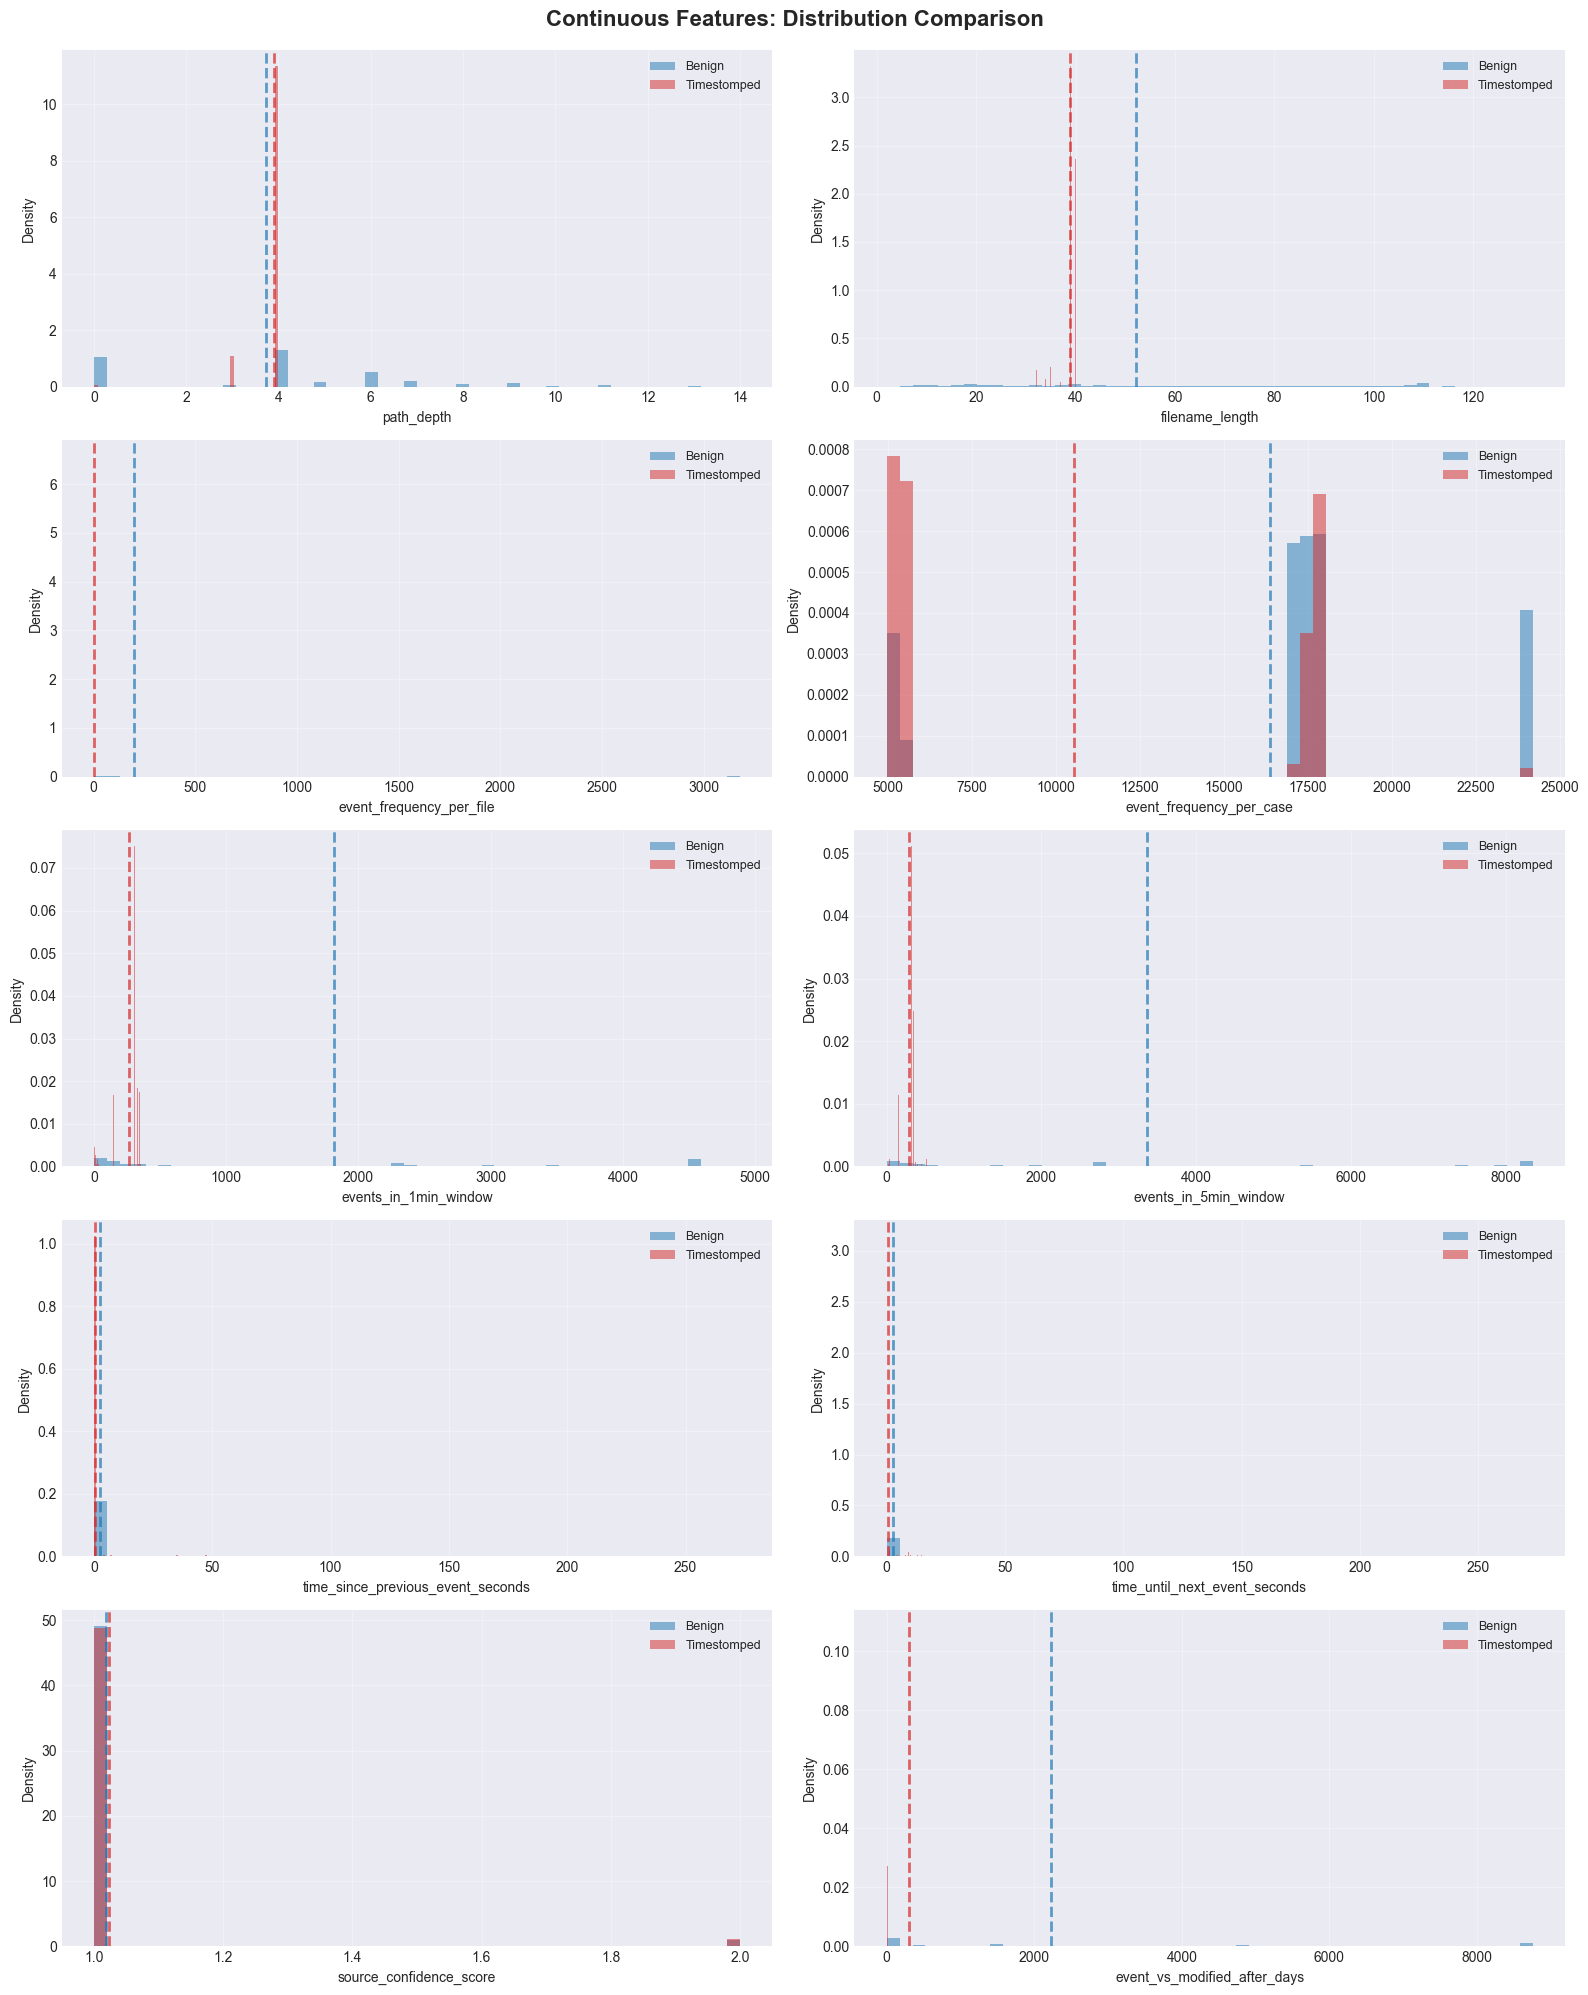

In [37]:
# Identify continuous features
continuous_features = [
    'path_depth', 'filename_length',
    'event_frequency_per_file', 'event_frequency_per_case',
    'events_in_1min_window', 'events_in_5min_window',
    'time_since_previous_event_seconds', 'time_until_next_event_seconds',
    'source_confidence_score', 'event_vs_modified_after_days'
]

# Calculate statistics for continuous features
cont_stats = []
for feature in continuous_features:
    # Filter out extreme outliers for better visualization (keep 99.9th percentile)
    ts_data = df[df['is_timestomped']][feature].dropna()
    benign_data = df[~df['is_timestomped']][feature].dropna()
    
    cont_stats.append({
        'feature': feature,
        'ts_mean': ts_data.mean(),
        'ts_median': ts_data.median(),
        'benign_mean': benign_data.mean(),
        'benign_median': benign_data.median(),
        'mean_ratio': ts_data.mean() / benign_data.mean() if benign_data.mean() != 0 else 0
    })

cont_df = pd.DataFrame(cont_stats)

print("\nContinuous Features - Statistics Comparison:")
print("=" * 100)
for _, row in cont_df.iterrows():
    print(f"{row['feature']:40s} | TS Mean: {row['ts_mean']:10.2f} | Benign Mean: {row['benign_mean']:10.2f} | Ratio: {row['mean_ratio']:.2f}x")

# Plot distributions
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.ravel()

for idx, feature in enumerate(continuous_features):
    ax = axes[idx]
    
    ts_data = df[df['is_timestomped']][feature].dropna()
    benign_data = df[~df['is_timestomped']][feature].dropna()
    
    # Use log scale for features with wide ranges
    if feature in ['time_since_previous_event_seconds', 'time_until_next_event_seconds']:
        # Cap at 99th percentile for better visualization
        cap = benign_data.quantile(0.99)
        ts_data_plot = ts_data[ts_data <= cap]
        benign_data_plot = benign_data[benign_data <= cap]
    else:
        ts_data_plot = ts_data
        benign_data_plot = benign_data
    
    # Plot histograms
    ax.hist(benign_data_plot, bins=50, alpha=0.5, label='Benign', color='#1f77b4', density=True)
    ax.hist(ts_data_plot, bins=50, alpha=0.5, label='Timestomped', color='#d62728', density=True)
    
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Add mean lines
    ax.axvline(benign_data_plot.mean(), color='#1f77b4', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(ts_data_plot.mean(), color='#d62728', linestyle='--', linewidth=2, alpha=0.7)

plt.suptitle('Continuous Features: Distribution Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'continuous_features_distribution.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: continuous_features_distribution.png")
plt.show()

## Step 6: Correlation Analysis

Calculate correlation matrix to identify redundant features (>0.95 correlation).


Highly Correlated Feature Pairs (|correlation| > 0.95):
source_confidence_score                  <-> has_logfile_evidence                     | Corr: 0.960
has_usnjrnl_evidence                     <-> usn_basic_info_change                    | Corr: 1.000
usn_file_closed                          <-> usn_complete_manipulation_pattern        | Corr: 1.000

✓ Saved: correlation_heatmap.png


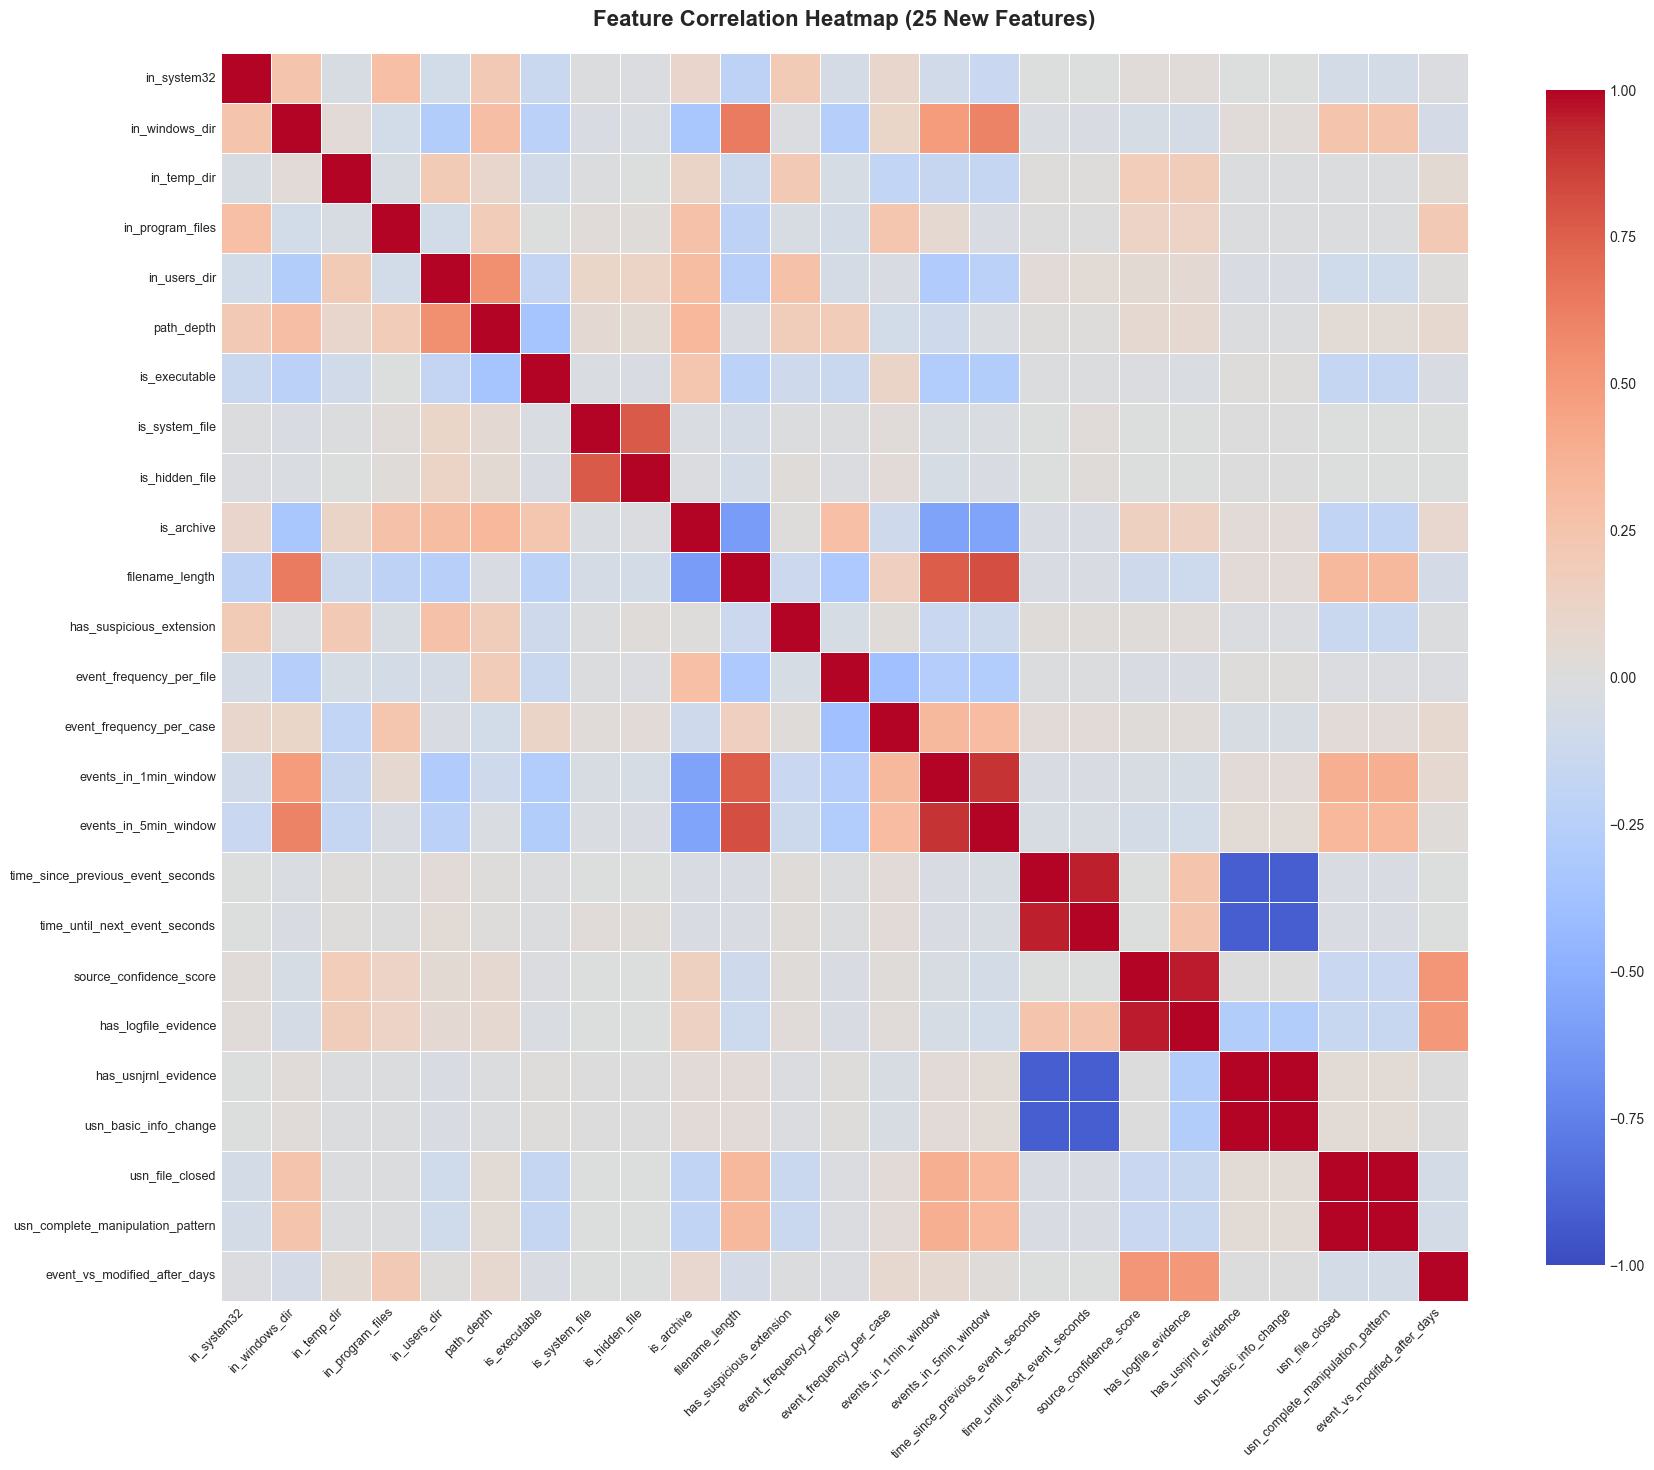

In [38]:
# Prepare features for correlation analysis
# Convert boolean to numeric
feature_df = df[all_new_features].copy()
for col in feature_df.columns:
    if feature_df[col].dtype == bool:
        feature_df[col] = feature_df[col].astype(int)

# Fill NaN values with median for continuous features
for col in continuous_features:
    if col in feature_df.columns:
        feature_df[col] = feature_df[col].fillna(feature_df[col].median())

# Calculate correlation matrix
corr_matrix = feature_df.corr()

# Find highly correlated pairs (>0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

print("\nHighly Correlated Feature Pairs (|correlation| > 0.95):")
print("=" * 80)
if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair['feature1']:40s} <-> {pair['feature2']:40s} | Corr: {pair['correlation']:.3f}")
else:
    print("✓ No highly correlated features found (good - low redundancy!)")

# Plot correlation heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (25 New Features)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: correlation_heatmap.png")
plt.show()

## Step 7: Feature Importance - Preliminary Random Forest

Train a Random Forest with all 25 features to get importance rankings.

In [39]:
# Prepare data for Random Forest
X = feature_df.copy()
y = df['is_timestomped'].astype(int)

print(f"Training data: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Class distribution: {y.sum():,} timestomped, {(~y.astype(bool)).sum():,} benign")

# Split data (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Train timestomped: {y_train.sum():,}")
print(f"Test timestomped: {y_test.sum():,}")

# Train Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("✓ Training complete!")

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance['importance_pct'] = feature_importance['importance'] * 100
feature_importance['cumulative_pct'] = feature_importance['importance_pct'].cumsum()

print("\nFeature Importance Rankings:")
print("=" * 90)
for idx, row in feature_importance.iterrows():
    print(f"{row['feature']:40s} | Importance: {row['importance_pct']:6.2f}% | Cumulative: {row['cumulative_pct']:6.2f}%")

# Save feature importance to CSV
feature_importance.to_csv(OUTPUT_DIR / 'feature_importance_rankings.csv', index=False)
print(f"\n✓ Saved: feature_importance_rankings.csv")

Training data: 154,550 samples, 25 features
Class distribution: 252 timestomped, 154,298 benign

Train set: 123,640 samples
Test set: 30,910 samples
Train timestomped: 202
Test timestomped: 50

Training Random Forest...
✓ Training complete!

Feature Importance Rankings:
in_temp_dir                              | Importance:  30.02% | Cumulative:  30.02%
event_frequency_per_file                 | Importance:  20.53% | Cumulative:  50.55%
events_in_5min_window                    | Importance:  11.30% | Cumulative:  61.85%
events_in_1min_window                    | Importance:   6.20% | Cumulative:  68.05%
filename_length                          | Importance:   5.65% | Cumulative:  73.70%
path_depth                               | Importance:   5.44% | Cumulative:  79.14%
is_archive                               | Importance:   5.38% | Cumulative:  84.52%
in_program_files                         | Importance:   3.16% | Cumulative:  87.68%
event_frequency_per_case                 | Import

## Step 8: Plot Feature Importance

✓ Saved: feature_importance_chart.png


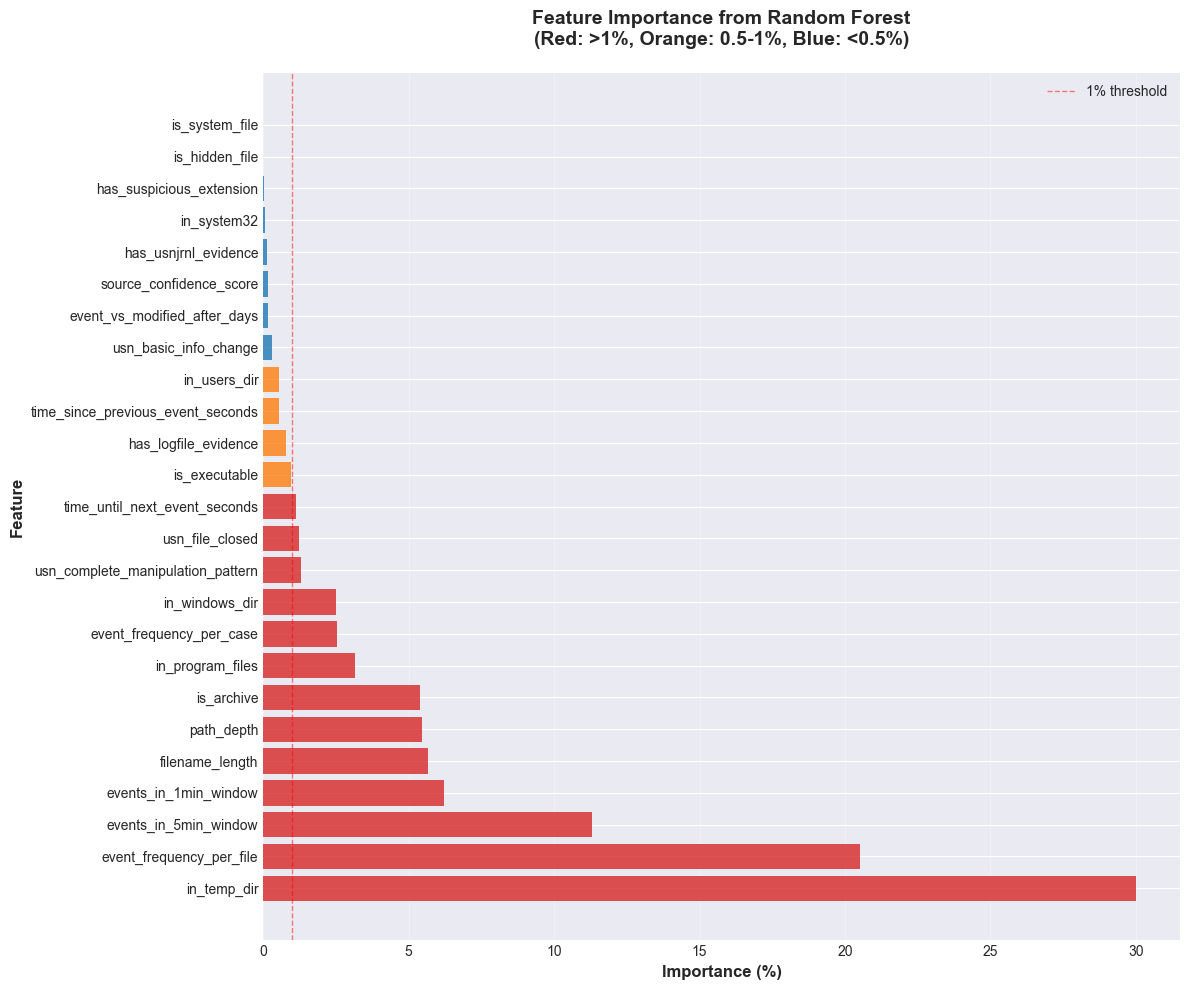

In [40]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#d62728' if imp >= 1.0 else '#ff7f0e' if imp >= 0.5 else '#1f77b4' 
          for imp in feature_importance['importance_pct']]

ax.barh(range(len(feature_importance)), feature_importance['importance_pct'], color=colors, alpha=0.8)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['feature'])
ax.set_xlabel('Importance (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance from Random Forest\n(Red: >1%, Orange: 0.5-1%, Blue: <0.5%)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='1% threshold')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_chart.png', dpi=150, bbox_inches='tight')
print("✓ Saved: feature_importance_chart.png")
plt.show()

## Step 9: Feature Selection

Select top features based on:
1. Remove features with <0.5% importance
2. Remove one feature from highly correlated pairs (>0.95)
3. Evaluate path_depth - keep if >1% importance, otherwise drop

In [41]:
# Define selection criteria
IMPORTANCE_THRESHOLD = 0.5  # Keep features with >0.5% importance

# Step 1: Filter by importance
selected_features = feature_importance[feature_importance['importance_pct'] >= IMPORTANCE_THRESHOLD]['feature'].tolist()

print(f"After importance filtering (>={IMPORTANCE_THRESHOLD}%):")
print(f"  Kept: {len(selected_features)} features")
print(f"  Removed: {len(all_new_features) - len(selected_features)} features")

# Show removed features
removed_low_importance = [f for f in all_new_features if f not in selected_features]
if removed_low_importance:
    print("\nRemoved (low importance):")
    for f in removed_low_importance:
        imp = feature_importance[feature_importance['feature'] == f]['importance_pct'].values[0]
        print(f"  - {f:40s} ({imp:.3f}%)")

# Step 2: Remove one from highly correlated pairs
if high_corr_pairs:
    print("\nHandling highly correlated pairs:")
    for pair in high_corr_pairs:
        f1, f2 = pair['feature1'], pair['feature2']
        if f1 in selected_features and f2 in selected_features:
            # Keep the one with higher importance
            imp1 = feature_importance[feature_importance['feature'] == f1]['importance_pct'].values[0]
            imp2 = feature_importance[feature_importance['feature'] == f2]['importance_pct'].values[0]
            
            if imp1 >= imp2:
                selected_features.remove(f2)
                print(f"  Removed {f2} (kept {f1} - higher importance: {imp1:.2f}% vs {imp2:.2f}%)")
            else:
                selected_features.remove(f1)
                print(f"  Removed {f1} (kept {f2} - higher importance: {imp2:.2f}% vs {imp1:.2f}%)")

# Step 3: Check path_depth specifically
if 'path_depth' in selected_features:
    pd_importance = feature_importance[feature_importance['feature'] == 'path_depth']['importance_pct'].values[0]
    print(f"\npath_depth: {pd_importance:.2f}% importance")
    if pd_importance >= 1.0:
        print("  ✓ Keeping path_depth (importance >= 1%)")
    else:
        print(f"  ⚠️ path_depth importance is low ({pd_importance:.2f}%), but keeping for now")
elif 'path_depth' in removed_low_importance:
    print("\npath_depth: Already removed due to low importance")

print(f"\n{'='*90}")
print(f"FINAL SELECTED FEATURES: {len(selected_features)}")
print(f"{'='*90}")

# Show final features sorted by importance
final_features_df = feature_importance[feature_importance['feature'].isin(selected_features)]
for idx, row in final_features_df.iterrows():
    print(f"{row['feature']:40s} | {row['importance_pct']:6.2f}%")

# Calculate cumulative importance of selected features
total_importance = final_features_df['importance_pct'].sum()
print(f"\nCumulative importance of selected features: {total_importance:.2f}%")

After importance filtering (>=0.5%):
  Kept: 17 features
  Removed: 8 features

Removed (low importance):
  - in_system32                              (0.061%)
  - is_system_file                           (0.002%)
  - is_hidden_file                           (0.002%)
  - has_suspicious_extension                 (0.028%)
  - source_confidence_score                  (0.167%)
  - has_usnjrnl_evidence                     (0.139%)
  - usn_basic_info_change                    (0.285%)
  - event_vs_modified_after_days             (0.177%)

Handling highly correlated pairs:
  Removed usn_file_closed (kept usn_complete_manipulation_pattern - higher importance: 1.31% vs 1.22%)

path_depth: 5.44% importance
  ✓ Keeping path_depth (importance >= 1%)

FINAL SELECTED FEATURES: 16
in_temp_dir                              |  30.02%
event_frequency_per_file                 |  20.53%
events_in_5min_window                    |  11.30%
events_in_1min_window                    |   6.20%
filename_length    

## Step 10: Create Final Curated Dataset

Create ML-ready dataset with selected features + baseline columns.

In [42]:
# Define baseline columns to keep (essential for analysis)
essential_columns = [
    'case_id', 'merge_key', 'filepath', 'filename',
    'eventtime', 'eventtime_dt',
    'source', 'is_timestomped',
    'lf_event', 'usn_event_info'
]

# Final columns = essential + selected features
final_columns = essential_columns + selected_features

# Create final dataset
df_final = df[final_columns].copy()

print(f"Final dataset:")
print(f"  Records: {len(df_final):,}")
print(f"  Columns: {len(df_final.columns)}")
print(f"    - Essential: {len(essential_columns)}")
print(f"    - Selected features: {len(selected_features)}")
print(f"  Timestomped: {df_final['is_timestomped'].sum():,}")
print(f"  Benign: {(~df_final['is_timestomped']).sum():,}")

# Verify data integrity
assert len(df_final) == len(df), "❌ Record count mismatch!"
assert df_final['is_timestomped'].sum() == 252, "❌ Timestomped count mismatch!"
print("\n✓ Data integrity verified")

# Save final dataset
output_file = OUTPUT_DIR / 'all_cases_combined_final_features.csv'
df_final.to_csv(output_file, index=False, encoding='utf-8-sig')

file_size_mb = output_file.stat().st_size / (1024 * 1024)

print(f"\n✓ Saved: all_cases_combined_final_features.csv ({file_size_mb:.1f} MB)")
print(f"\nColumn breakdown:")
print(f"  Essential columns: {essential_columns}")
print(f"  Selected features ({len(selected_features)}): {selected_features}")

Final dataset:
  Records: 154,550
  Columns: 26
    - Essential: 10
    - Selected features: 16
  Timestomped: 252
  Benign: 154,298

✓ Data integrity verified

✓ Saved: all_cases_combined_final_features.csv (69.0 MB)

Column breakdown:
  Essential columns: ['case_id', 'merge_key', 'filepath', 'filename', 'eventtime', 'eventtime_dt', 'source', 'is_timestomped', 'lf_event', 'usn_event_info']
  Selected features (16): ['in_temp_dir', 'event_frequency_per_file', 'events_in_5min_window', 'events_in_1min_window', 'filename_length', 'path_depth', 'is_archive', 'in_program_files', 'event_frequency_per_case', 'in_windows_dir', 'usn_complete_manipulation_pattern', 'time_until_next_event_seconds', 'is_executable', 'has_logfile_evidence', 'time_since_previous_event_seconds', 'in_users_dir']


## Step 11: Generate Feature Quality Report

In [43]:
# Create comprehensive feature quality report
report = f"""# Phase 2C Feature Quality Analysis Report

**Date**: {pd.Timestamp.now().strftime('%Y-%m-%d')}
**Input**: Phase 2B output (63 columns, 154,550 records)
**Output**: Final curated dataset ({len(selected_features)} features)

---

## Summary

- **Total features analyzed**: 25
- **Features selected**: {len(selected_features)}
- **Features removed**: {len(all_new_features) - len(selected_features)}
- **Selection criteria**: Importance >= {IMPORTANCE_THRESHOLD}%, correlation < 0.95
- **Cumulative importance**: {total_importance:.2f}%

---

## Selected Features ({len(selected_features)})

| Rank | Feature | Importance (%) | Group |
|----|---------|----------------|-------|
"""

for idx, row in final_features_df.iterrows():
    feature = row['feature']
    importance = row['importance_pct']
    
    # Determine group
    if feature in location_features:
        group = 'Location'
    elif feature in file_type_features:
        group = 'File Type'
    elif feature in temporal_features:
        group = 'Temporal'
    elif feature in cross_artifact_features:
        group = 'Cross-Artifact'
    elif feature in pattern_features:
        group = 'Pattern'
    else:
        group = 'Event-Time'
    
    rank = final_features_df.index.tolist().index(idx) + 1
    report += f"| {rank} | `{feature}` | {importance:.2f} | {group} |\\n"

report += f"""\\n---

## Removed Features ({len(removed_low_importance)})

| Feature | Importance (%) | Reason |
|---------|----------------|--------|
"""

for f in removed_low_importance:
    imp = feature_importance[feature_importance['feature'] == f]['importance_pct'].values[0]
    report += f"| `{f}` | {imp:.3f} | Low importance (<{IMPORTANCE_THRESHOLD}%) |\\n"

if high_corr_pairs:
    report += "\\n## Highly Correlated Pairs\\n\\n"
    for pair in high_corr_pairs:
        report += f"- `{pair['feature1']}` <-> `{pair['feature2']}` (r={pair['correlation']:.3f})\\n"
else:
    report += "\\n## Correlation Analysis\\n\\nNo highly correlated features found (>0.95). Low redundancy confirmed.\\n"

report += f"""\\n---

## Data Integrity

- ✓ Total records: {len(df_final):,} (unchanged)
- ✓ Timestomped events: {df_final['is_timestomped'].sum():,} (unchanged)
- ✓ Benign events: {(~df_final['is_timestomped']).sum():,} (unchanged)

---

## Files Generated

1. **Final Dataset**: `all_cases_combined_final_features.csv` ({len(selected_features)} features + {len(essential_columns)} essential columns)
2. **Feature Importance**: `feature_importance_rankings.csv`
3. **Visualizations**:
   - `boolean_features_distribution.png`
   - `continuous_features_distribution.png`
   - `correlation_heatmap.png`
   - `feature_importance_chart.png`

---

## Next Steps

**Phase 3: Baseline Model Training**
- Train 5 ML algorithms (Random Forest, Logistic Regression, XGBoost, LightGBM, Neural Network)
- Evaluate performance with selected features
- Compare model performance
- Select best model for production

---

## Conclusion

Feature selection complete. Selected {len(selected_features)} high-quality features representing {total_importance:.2f}% of total feature importance. Dataset is ML-ready for Phase 3 baseline model training.
"""

# Save report
report_file = OUTPUT_DIR / 'FEATURE_QUALITY_REPORT.md'
with open(report_file, 'w') as f:
    f.write(report)

print("\\n✓ Saved: FEATURE_QUALITY_REPORT.md")
print("\\n" + "="*90)
print("PHASE 2C COMPLETE!")
print("="*90)
print(f"\\nFinal dataset ready for Phase 3: {len(selected_features)} features selected")
print(f"Output location: {OUTPUT_DIR}")

\n✓ Saved: FEATURE_QUALITY_REPORT.md
\n==========================================================================================
PHASE 2C COMPLETE!
\nFinal dataset ready for Phase 3: 16 features selected
Output location: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2C - Feature Quality
